# YieldSAT Crop-Mapping Baseline

This notebook trains clean crop-mapping baselines from the two YieldSAT feature-store outputs: `crop_mapping_fields.parquet` and `crop_mapping_observations.parquet`. It replaces the old raw-raster prototype with a shorter workflow that uses balanced `wheat`, `corn`, and `other` labels, grouped validation, tabular feature importance, and optional sequence-model feature importance.


## 1. Import Dependencies


In [ ]:
import random
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch device:", DEVICE)


TensorFlow available: False


## 2. Configuration

Set `FEATURE_STORE_DIR` to the folder that contains `crop_mapping_fields.parquet` and `crop_mapping_observations.parquet`, then run the notebook.


In [ ]:
RANDOM_SEED = 42
TARGET_LABELS = ["wheat", "corn", "other"]
OTHER_SOURCE_CROPS = ["soybean", "rapeseed"]
N_SEQUENCE_STEPS = 20
N_SPLITS = 5

RUN_SEQUENCE_MODEL = True
INCLUDE_METADATA_FEATURES = False

FEATURE_STORE_DIR = Path("/content/yieldsat_crop_mapping_feature_store")

FIELDS_PATH = FEATURE_STORE_DIR / "crop_mapping_fields.parquet"
OBSERVATIONS_PATH = FEATURE_STORE_DIR / "crop_mapping_observations.parquet"

print("Feature store directory:", FEATURE_STORE_DIR)
print("Fields path:", FIELDS_PATH)
print("Observations path:", OBSERVATIONS_PATH)
print("Run sequence model:", RUN_SEQUENCE_MODEL)


Feature store directory: data\yieldsat_crop_mapping_feature_store
Fields path: data\yieldsat_crop_mapping_feature_store\crop_mapping_fields.parquet
Observations path: data\yieldsat_crop_mapping_feature_store\crop_mapping_observations.parquet
Run sequence model: False


## 3. Load Feature Store

This section reads the two feature-store tables and performs basic leakage checks. The model target is `crop`; yield-derived columns are rejected from training features.

In [3]:
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

if not FIELDS_PATH.exists():
    raise FileNotFoundError(f"Missing fields table: {FIELDS_PATH}")
if not OBSERVATIONS_PATH.exists():
    raise FileNotFoundError(f"Missing observations table: {OBSERVATIONS_PATH}")

fields = pd.read_parquet(FIELDS_PATH)
observations = pd.read_parquet(OBSERVATIONS_PATH)

fields["crop"] = fields["crop"].astype(str).str.lower()
if "country" not in fields.columns:
    fields["country"] = fields.get("adm_country", "unknown")
fields["country"] = fields["country"].fillna("unknown").astype(str)
fields["year"] = fields["year"].astype(str)
fields["country_year"] = fields["country"] + "_" + fields["year"]

print("Fields:", fields.shape)
print("Observations:", observations.shape)
print("Crop counts:")
print(fields["crop"].value_counts(dropna=False))
print("Countries:")
print(fields["country"].value_counts(dropna=False))

leakage_terms = ("yield", "target")
field_leakage_cols = [col for col in fields.columns if any(term in col.lower() for term in leakage_terms)]
obs_leakage_cols = [col for col in observations.columns if any(term in col.lower() for term in leakage_terms)]
print("Potential field leakage columns present but excluded:", field_leakage_cols)
print("Potential observation leakage columns present but excluded:", obs_leakage_cols)


Fields: (2173, 936)
Observations: (100670, 258)
Crop counts:
crop
soybean     1305
wheat        454
corn         303
rapeseed     111
Name: count, dtype: int64
Countries:
country
Argentina    751
Uruguay      572
Brazil       551
Germany      299
Name: count, dtype: int64
Potential field leakage columns present but excluded: ['yieldmap_quality']
Potential observation leakage columns present but excluded: []


## 4. Build Wheat / Corn / Other Dataset

The target stays compatible with the PR #10 objective: `wheat`, `corn`, and `other`. This version keeps all wheat fields and all corn fields, then samples `other` from soybean and rapeseed to match the wheat count with a country-balancing pass.


In [4]:
def sample_n(df: pd.DataFrame, n: int, seed: int) -> pd.DataFrame:
    if len(df) < n:
        raise ValueError(f"Cannot sample {n} rows from only {len(df)} candidates")
    return df.sample(n=n, random_state=seed).copy()


def sample_other_balanced_by_country(fields_df: pd.DataFrame, n: int, seed: int) -> pd.DataFrame:
    candidates = fields_df[fields_df["crop"].isin(OTHER_SOURCE_CROPS)].copy()
    countries = sorted(candidates["country"].dropna().unique())
    if not countries:
        raise ValueError("No other-class candidates were found")

    per_country = n // len(countries)
    remainder = n % len(countries)
    sampled_parts = []
    used_indexes = set()

    for idx, country in enumerate(countries):
        country_candidates = candidates[candidates["country"] == country]
        country_target = per_country + (1 if idx < remainder else 0)
        take = min(country_target, len(country_candidates))
        if take > 0:
            part = country_candidates.sample(n=take, random_state=seed + idx)
            sampled_parts.append(part)
            used_indexes.update(part.index.tolist())

    sampled = pd.concat(sampled_parts, axis=0) if sampled_parts else candidates.iloc[0:0].copy()
    shortfall = n - len(sampled)
    if shortfall > 0:
        remaining = candidates.drop(index=list(used_indexes), errors="ignore")
        if len(remaining) < shortfall:
            raise ValueError(f"Need {shortfall} additional other samples, only {len(remaining)} remain")
        sampled = pd.concat([
            sampled,
            remaining.sample(n=shortfall, random_state=seed + 999),
        ], axis=0)

    return sampled.sample(frac=1.0, random_state=seed + 1999).copy()


wheat_candidates = fields[fields["crop"] == "wheat"].copy()
corn_candidates = fields[fields["crop"] == "corn"].copy()
other_candidates = fields[fields["crop"].isin(OTHER_SOURCE_CROPS)].copy()

n_other = len(wheat_candidates)
print("Candidates:", {"wheat": len(wheat_candidates), "corn": len(corn_candidates), "other": len(other_candidates)})
print("Using all wheat fields:", len(wheat_candidates))
print("Using all corn fields:", len(corn_candidates))
print("Other samples to draw:", n_other)

wheat_sample = wheat_candidates.copy()
corn_sample = corn_candidates.copy()
other_sample = sample_other_balanced_by_country(fields, n_other, RANDOM_SEED + 3)
other_sample["source_crop"] = other_sample["crop"]

wheat_sample["label"] = "wheat"
corn_sample["label"] = "corn"
other_sample["label"] = "other"

selected_fields = pd.concat([wheat_sample, corn_sample, other_sample], ignore_index=True)
selected_fields = selected_fields.sample(frac=1.0, random_state=RANDOM_SEED).reset_index(drop=True)

print("Selected fields:", selected_fields.shape)
print("Label counts:")
print(selected_fields["label"].value_counts())
print("Label x country:")
print(pd.crosstab(selected_fields["label"], selected_fields["country"]))
print("Other source crop x country:")
print(pd.crosstab(other_sample["source_crop"], other_sample["country"]))


Candidates: {'wheat': 454, 'corn': 303, 'other': 1416}
Using all wheat fields: 454
Using all corn fields: 303
Other samples to draw: 454
Selected fields: (1211, 938)
Label counts:
label
wheat    454
other    454
corn     303
Name: count, dtype: int64
Label x country:
country  Argentina  Brazil  Germany  Uruguay
label                                       
corn           185     118        0        0
other          116     114      111      113
wheat          126     140      188        0
Other source crop x country:
country      Argentina  Brazil  Germany  Uruguay
source_crop                                     
rapeseed             0       0      111        0
soybean            116     114        0      113


## 5. Aggregate Observation Features For Tabular Modeling

The tabular baseline uses the observation-level feature store rather than raw rasters. It aggregates dynamic Sentinel-2, SCL, weather, and season-position columns per field, then joins static DEM/soil/area fields.

In [5]:
def is_leakage_column(col: str) -> bool:
    lower = col.lower()
    return any(term in lower for term in ("yield", "target")) or lower == "crop"


def numeric_feature_columns(df: pd.DataFrame, excluded: set[str]) -> list[str]:
    cols = []
    for col in df.columns:
        if col in excluded or is_leakage_column(col):
            continue
        if pd.api.types.is_bool_dtype(df[col]) or pd.api.types.is_numeric_dtype(df[col]):
            cols.append(col)
    return cols


selected_ids = set(selected_fields["field_id"].astype(str))
obs = observations[observations["field_id"].astype(str).isin(selected_ids)].copy()
obs["field_id"] = obs["field_id"].astype(str)
selected_fields["field_id"] = selected_fields["field_id"].astype(str)

for col in obs.columns:
    if pd.api.types.is_bool_dtype(obs[col]):
        obs[col] = obs[col].astype("int8")

obs_excluded = {"field_id", "date", "crop", "label"}
obs_feature_cols = numeric_feature_columns(obs, obs_excluded)

if not obs_feature_cols:
    raise RuntimeError("No numeric observation features were found")

obs_agg_mean = obs.groupby("field_id")[obs_feature_cols].mean().add_prefix("obs_mean__")
obs_agg_std = obs.groupby("field_id")[obs_feature_cols].std().add_prefix("obs_std__")
obs_agg_min = obs.groupby("field_id")[obs_feature_cols].min().add_prefix("obs_min__")
obs_agg_max = obs.groupby("field_id")[obs_feature_cols].max().add_prefix("obs_max__")
obs_agg_p10 = obs.groupby("field_id")[obs_feature_cols].quantile(0.10).add_prefix("obs_p10__")
obs_agg_p90 = obs.groupby("field_id")[obs_feature_cols].quantile(0.90).add_prefix("obs_p90__")

obs_agg = pd.concat([
    obs_agg_mean,
    obs_agg_std,
    obs_agg_min,
    obs_agg_max,
    obs_agg_p10,
    obs_agg_p90,
], axis=1).reset_index()

static_excluded = {
    "field_id", "field_shared_name", "metadata_path", "crop", "label", "source_crop",
    "country", "provider", "farm", "field_num", "year", "country_year",
    "adm_country", "adm_1", "adm_2", "adm_3", "adm_4",
    "seeding_date", "harvesting_date", "seeding_date_type", "yieldmap_quality", "quality_density",
}
static_feature_cols = numeric_feature_columns(selected_fields, static_excluded)

if INCLUDE_METADATA_FEATURES:
    metadata_dummies = pd.get_dummies(selected_fields[["country", "provider", "year"]].astype(str), prefix=["country", "provider", "year"])
else:
    metadata_dummies = pd.DataFrame(index=selected_fields.index)

static_part = selected_fields[["field_id", "label", "crop", "country", "year", "country_year"] + static_feature_cols].copy()
if not metadata_dummies.empty:
    static_part = pd.concat([static_part.reset_index(drop=True), metadata_dummies.reset_index(drop=True)], axis=1)

model_table = static_part.merge(obs_agg, on="field_id", how="inner")
model_table = model_table.replace([np.inf, -np.inf], np.nan)

all_feature_cols = [
    col for col in model_table.columns
    if col not in {"field_id", "label", "crop", "country", "year", "country_year"}
    and not is_leakage_column(col)
]
feature_cols = all_feature_cols.copy()

print("Model table:", model_table.shape)
print("All feature columns before manual selection:", len(all_feature_cols))
print("Rows lost due to missing observations:", len(selected_fields) - len(model_table))
print("Final label counts:")
print(model_table["label"].value_counts())

assert not any(is_leakage_column(col) for col in all_feature_cols), "Leakage column included in features"


Model table: (1211, 2457)
All feature columns before manual selection: 2451
Rows lost due to missing observations: 0
Final label counts:
label
wheat    454
other    454
corn     303
Name: count, dtype: int64


## 6. Explore Feature Groups

This cell shows the feature groups before training. Read the group counts and examples, then edit the next cell if you want to add or remove groups or exact feature names.

In [6]:
S2_BANDS = ("B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B09", "B11", "B12")
VEGETATION_INDICES = ("NDVI", "SAVI", "EVI", "GNDVI", "NDWI_GREEN", "NDRE", "NDMI", "MSI", "NBR", "BSI", "CAI_B01_B08")
SEASON_POSITION_FEATURES = {"doy", "days_after_seeding", "days_before_harvest", "season_progress", "in_declared_season"}


def base_feature_name(feature: str) -> str:
    if feature.startswith("obs_") and "__" in feature:
        return feature.split("__", 1)[1]
    return feature


def feature_group(feature: str) -> str:
    base = base_feature_name(feature)

    if feature.startswith("dem_"):
        return "DEM/slope/aspect"
    if feature.startswith("soil_"):
        return "SoilGrids soil features"
    if base.startswith("weather_"):
        return "Weather/GDD/rain/temp"
    if base.startswith("scl_"):
        return "SCL/cloud fractions"
    if base in {"s2_total_pixel_count", "s2_valid_pixel_count", "s2_valid_pixel_fraction"}:
        return "Pixel/valid counts"
    if base.startswith("s2_") and base.endswith("_count"):
        return "Pixel/valid counts"
    if any(base.startswith(f"s2_{index}_") for index in VEGETATION_INDICES):
        return "Vegetation indices"
    if any(base.startswith(f"s2_{band}_") for band in S2_BANDS):
        return "Sentinel-2 bands"
    if base in SEASON_POSITION_FEATURES:
        return "Season/date position"
    if feature == "area_calculated_ha":
        return "Area from bbox"
    if feature in {"season_length_days", "centroid_lat", "centroid_lon", "crs_epsg", "moisture_pct"}:
        return "Other static fields"
    return "Other"


feature_audit = pd.DataFrame({"feature": all_feature_cols})
feature_audit["base_feature"] = feature_audit["feature"].map(base_feature_name)
feature_audit["feature_group"] = feature_audit["feature"].map(feature_group)

feature_group_counts = (
    feature_audit.groupby("feature_group", as_index=False)
    .agg(count=("feature", "size"))
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

print("Feature groups before training:")
display(feature_group_counts)

print("Example features from each group:")
display(
    feature_audit.sort_values(["feature_group", "feature"])
    .groupby("feature_group")
    .head(12)
    .reset_index(drop=True)
)

Feature groups before training:


,feature_group,count
0,SoilGrids soil features,864
1,Sentinel-2 bands,576
2,Vegetation indices,528
3,Weather/GDD/rain/temp,162
4,Pixel/valid counts,156
5,SCL/cloud fractions,84
6,DEM/slope/aspect,45
7,Season/date position,30
8,Other static fields,5
9,Area from bbox,1


Example features from each group:


,feature,base_feature,feature_group
0,area_calculated_ha,area_calculated_ha,Area from bbox
1,dem_aspect_count,dem_aspect_count,DEM/slope/aspect
2,dem_aspect_max,dem_aspect_max,DEM/slope/aspect
3,dem_aspect_mean,dem_aspect_mean,DEM/slope/aspect
4,dem_aspect_min,dem_aspect_min,DEM/slope/aspect
...,...,...,...
97,obs_max__weather_30d_rainy_days,weather_30d_rainy_days,Weather/GDD/rain/temp
98,obs_max__weather_7d_Temp_mean_C,weather_7d_Temp_mean_C,Weather/GDD/rain/temp
99,obs_max__weather_7d_Total_prec_mm,weather_7d_Total_prec_mm,Weather/GDD/rain/temp
100,obs_max__weather_7d_gdd_base10,weather_7d_gdd_base10,Weather/GDD/rain/temp


## 7. Choose Features For This Run

This is the manual selection cell. Keep the groups you want, add exact feature names to `EXTRA_EXCLUDE_FEATURES` if the exploration output shows something you do not want, then rerun from this cell onward.

In [ ]:
TRAINING_FEATURE_GROUPS = [
    "Sentinel-2 bands",
    "Vegetation indices",
    "SCL/cloud fractions",
    "Pixel/valid counts",
    "DEM/slope/aspect",
    "SoilGrids soil features",
    "Weather/GDD/rain/temp",
]

EXTRA_EXCLUDE_FEATURES = [
    # Example: "obs_mean__s2_B01_count",
]

feature_cols = feature_audit.loc[
    feature_audit["feature_group"].isin(TRAINING_FEATURE_GROUPS),
    "feature",
].tolist()
feature_cols = [feature for feature in feature_cols if feature not in set(EXTRA_EXCLUDE_FEATURES)]

selected_feature_audit = feature_audit[feature_audit["feature"].isin(feature_cols)].copy()
excluded_feature_audit = feature_audit[~feature_audit["feature"].isin(feature_cols)].copy()

print("Selected training features:", len(feature_cols))
print("Excluded features:", len(excluded_feature_audit))

print("Selected feature groups:")
display(
    selected_feature_audit.groupby("feature_group", as_index=False)
    .agg(count=("feature", "size"))
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

print("Excluded feature groups:")
display(
    excluded_feature_audit.groupby("feature_group", as_index=False)
    .agg(count=("feature", "size"))
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

print("First selected features:")
display(selected_feature_audit.head(30))

if not feature_cols:
    raise RuntimeError("No training features were selected. Edit TRAINING_FEATURE_GROUPS and rerun this cell.")


Selected training features: 1344
Excluded features: 1107
Selected feature groups:


,feature_group,count
0,Sentinel-2 bands,576
1,Vegetation indices,528
2,Pixel/valid counts,156
3,SCL/cloud fractions,84


Excluded feature groups:


,feature_group,count
0,SoilGrids soil features,864
1,Weather/GDD/rain/temp,162
2,DEM/slope/aspect,45
3,Season/date position,30
4,Other static fields,5
5,Area from bbox,1


First selected features:


,feature,base_feature,feature_group
947,obs_mean__s2_total_pixel_count,s2_total_pixel_count,Pixel/valid counts
948,obs_mean__s2_valid_pixel_count,s2_valid_pixel_count,Pixel/valid counts
949,obs_mean__s2_valid_pixel_fraction,s2_valid_pixel_fraction,Pixel/valid counts
950,obs_mean__scl_nodata_fraction,scl_nodata_fraction,SCL/cloud fractions
951,obs_mean__scl_saturated_or_defective_fraction,scl_saturated_or_defective_fraction,SCL/cloud fractions
952,obs_mean__scl_dark_area_fraction,scl_dark_area_fraction,SCL/cloud fractions
953,obs_mean__scl_cloud_shadow_fraction,scl_cloud_shadow_fraction,SCL/cloud fractions
954,obs_mean__scl_vegetation_fraction,scl_vegetation_fraction,SCL/cloud fractions
955,obs_mean__scl_bare_soil_fraction,scl_bare_soil_fraction,SCL/cloud fractions
956,obs_mean__scl_water_fraction,scl_water_fraction,SCL/cloud fractions


## 8. Grouped Train/Test Split

The split groups fields by `country_year`, so fields from the same country and crop year do not appear in both train and test. This is stricter than a random split and avoids the biggest optimism problem in the old baseline notebook.


In [16]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(model_table["label"])
X = model_table[feature_cols]
groups = model_table["country_year"].astype(str).values

n_splits = min(N_SPLITS, len(np.unique(groups)))
if n_splits < 2:
    raise RuntimeError("Need at least two country_year groups for grouped validation")

splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]
train_meta = model_table.iloc[train_idx].copy()
test_meta = model_table.iloc[test_idx].copy()

print("Train shape:", X_train.shape, Counter(label_encoder.inverse_transform(y_train)))
print("Test shape:", X_test.shape, Counter(label_encoder.inverse_transform(y_test)))
print("Train groups:", len(np.unique(train_meta["country_year"])))
print("Test groups:", len(np.unique(test_meta["country_year"])))
print("Held-out groups:", sorted(test_meta["country_year"].unique()))

Train shape: (951, 1344) Counter({'wheat': 371, 'other': 365, 'corn': 215})
Test shape: (260, 1344) Counter({'other': 89, 'corn': 88, 'wheat': 83})
Train groups: 22
Test groups: 6
Held-out groups: ['Argentina_2019', 'Argentina_2022', 'Brazil_2017', 'Brazil_2022', 'Germany_2016', 'Uruguay_2021']


## 9. Tabular XGBoost And CatBoost Baselines

This section trains XGBoost and CatBoost on the exact same grouped train/test split and feature table. The comparison is model-to-model only; data selection, leakage rules, imputation, and labels are held constant.


In [17]:
xgb_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )),
])

cat_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", CatBoostClassifier(
        iterations=300,
        depth=5,
        learning_rate=0.05,
        loss_function="MultiClass",
        random_seed=RANDOM_SEED,
        verbose=False,
        allow_writing_files=False,
    )),
])

tabular_pipelines = {
    "xgboost": xgb_model,
    "catboost": cat_model,
}

tabular_results = []
tabular_predictions = {}

for model_name, model in tabular_pipelines.items():
    print(f"Training {model_name}...")
    model.fit(X_train, y_train)

    pred = np.asarray(model.predict(X_test)).reshape(-1)
    tabular_predictions[model_name] = pred

    accuracy = accuracy_score(y_test, pred)
    macro_f1 = f1_score(y_test, pred, average="macro")
    tabular_results.append({
        "model": model_name,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
    })

    print(f"\n{model_name}")
    print("accuracy:", accuracy)
    print("macro F1:", macro_f1)
    print("Confusion matrix:")
    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred, target_names=label_encoder.classes_))

comparison_df = pd.DataFrame(tabular_results).sort_values("macro_f1", ascending=False).reset_index(drop=True)
display(comparison_df)

best_tabular_model_name = comparison_df.iloc[0]["model"]
best_tabular_pipeline = tabular_pipelines[best_tabular_model_name]
print("Best tabular model by macro F1:", best_tabular_model_name)


Training xgboost...

xgboost
accuracy: 0.9153846153846154
macro F1: 0.9146175345060715
Confusion matrix:
[[74  2 12]
 [ 0 87  2]
 [ 1  5 77]]
              precision    recall  f1-score   support

        corn       0.99      0.84      0.91        88
       other       0.93      0.98      0.95        89
       wheat       0.85      0.93      0.89        83

    accuracy                           0.92       260
   macro avg       0.92      0.92      0.91       260
weighted avg       0.92      0.92      0.92       260

Training catboost...

catboost
accuracy: 0.8807692307692307
macro F1: 0.8792108041827037
Confusion matrix:
[[68  3 17]
 [ 0 87  2]
 [ 1  8 74]]
              precision    recall  f1-score   support

        corn       0.99      0.77      0.87        88
       other       0.89      0.98      0.93        89
       wheat       0.80      0.89      0.84        83

    accuracy                           0.88       260
   macro avg       0.89      0.88      0.88       260
weighte

,model,accuracy,macro_f1
0,xgboost,0.915385,0.914618
1,catboost,0.880769,0.879211


Best tabular model by macro F1: xgboost


## 10. Tabular Feature Importance For Both Models

This section reports native feature importance for XGBoost and CatBoost separately. It also groups importance by feature source so we can compare whether the models rely more on Sentinel-2, SCL, weather, soil, DEM, or production-quality signals.


Top xgboost features:


,feature,importance,source,model
0,obs_p90__s2_NDMI_p90,0.022113,s2,xgboost
1,obs_mean__s2_B06_p90,0.021956,s2,xgboost
2,obs_max__s2_GNDVI_p90,0.018170,s2,xgboost
3,obs_min__s2_B04_mean,0.017159,s2,xgboost
4,obs_p10__s2_B04_p10,0.015629,s2,xgboost
5,obs_p90__s2_B08_p90,0.014905,s2,xgboost
6,obs_mean__s2_valid_pixel_fraction,0.013793,s2,xgboost
7,obs_p90__s2_MSI_p25,0.012789,s2,xgboost
8,obs_std__s2_MSI_p90,0.010763,s2,xgboost
9,obs_p90__s2_NDRE_mean,0.010700,s2,xgboost


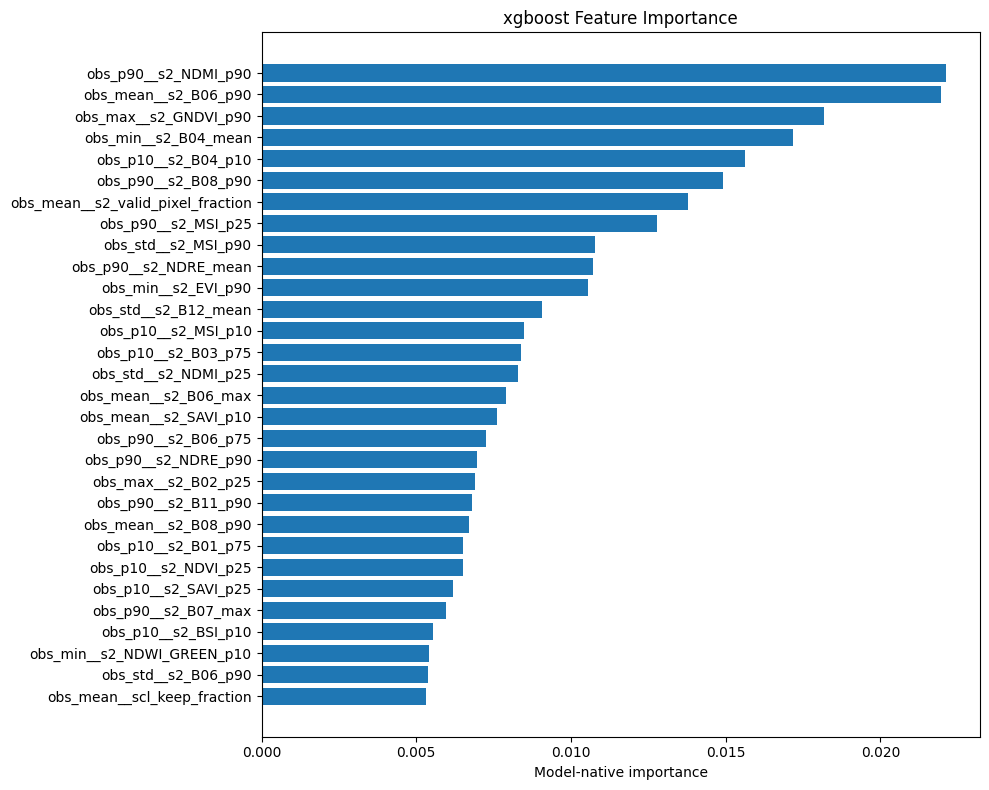

Top catboost features:


,feature,importance,source,model
0,obs_p90__s2_B06_p75,6.290797,s2,catboost
1,obs_p90__s2_NDMI_p90,3.321303,s2,catboost
2,obs_p10__s2_B11_p25,2.455503,s2,catboost
3,obs_p90__s2_NDRE_p75,2.447283,s2,catboost
4,obs_p10__s2_MSI_p10,2.319890,s2,catboost
5,obs_max__s2_NDVI_p90,2.227374,s2,catboost
6,obs_p10__s2_MSI_p25,2.205455,s2,catboost
7,obs_min__s2_BSI_p10,2.179041,s2,catboost
8,obs_mean__s2_B06_p75,1.910411,s2,catboost
9,obs_p10__s2_B11_mean,1.814414,s2,catboost


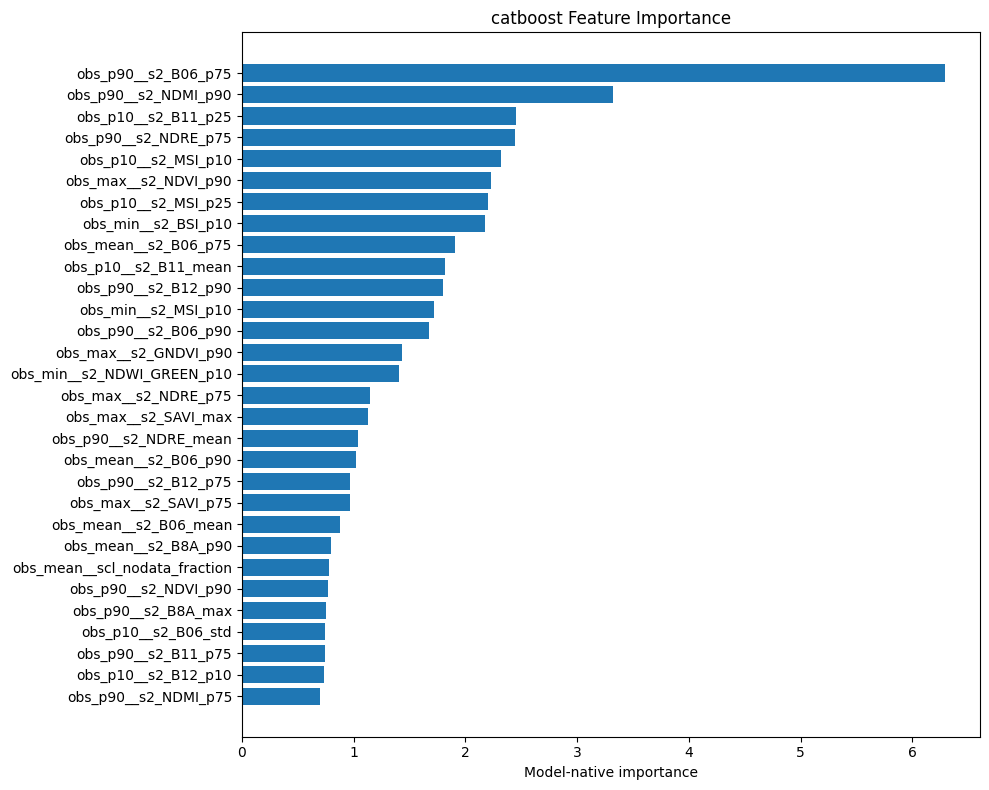

Importance by source and model:


model,source,catboost,xgboost
0,s2,96.272373,0.962561
1,scl,3.727627,0.037439


In [19]:
def feature_source(name: str) -> str:
    if name.startswith("obs_"):
        parts = name.split("__", 1)
        if len(parts) == 2:
            inner = parts[1]
            if inner.startswith("s2_"):
                return "s2"
            if inner.startswith("scl_"):
                return "scl"
            if inner.startswith("weather_"):
                return "weather"
            if inner in {"doy", "days_after_seeding", "days_before_harvest", "season_progress", "in_declared_season"}:
                return "season_position"
        return "observation"
    if name.startswith("dem_"):
        return "dem"
    if name.startswith("soil_"):
        return "soil"
    return "static_or_metadata"


def get_native_importance(model_name: str, model_pipeline: Pipeline) -> np.ndarray:
    fitted_model = model_pipeline.named_steps["model"]
    if model_name == "catboost":
        return fitted_model.get_feature_importance()
    return fitted_model.feature_importances_


tabular_importances = {}
source_importances = []

for model_name, model_pipeline in tabular_pipelines.items():
    importance_values = get_native_importance(model_name, model_pipeline)
    importance_df = (
        pd.DataFrame({"feature": feature_cols, "importance": importance_values})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
    importance_df["source"] = importance_df["feature"].map(feature_source)
    importance_df["model"] = model_name
    tabular_importances[model_name] = importance_df

    print(f"Top {model_name} features:")
    display(importance_df.head(30))

    grouped = (
        importance_df.groupby("source", as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
    )
    grouped["model"] = model_name
    source_importances.append(grouped)

    plt.figure(figsize=(10, 8))
    plot_df = importance_df.head(30).iloc[::-1]
    plt.barh(plot_df["feature"], plot_df["importance"])
    plt.title(f"{model_name} Feature Importance")
    plt.xlabel("Model-native importance")
    plt.tight_layout()
    plt.show()

source_importance_df = pd.concat(source_importances, ignore_index=True)
print("Importance by source and model:")
display(source_importance_df.pivot_table(index="source", columns="model", values="importance", fill_value=0).reset_index())


## 11. Build Sequence Tensor From Observation Rows

The sequence model uses the same selected fields and same held-out groups, but keeps observations as a fixed-length time series. This section is optional because `RUN_SEQUENCE_MODEL` is `False` by default.


In [ ]:
def sequence_feature_group(feature: str) -> str:
    if feature.startswith("weather_"):
        return "Weather/GDD/rain/temp"
    if feature.startswith("scl_"):
        return "SCL/cloud fractions"
    if feature in {"s2_total_pixel_count", "s2_valid_pixel_count", "s2_valid_pixel_fraction"}:
        return "Pixel/valid counts"
    if feature.startswith("s2_") and feature.endswith("_count"):
        return "Pixel/valid counts"
    if any(feature.startswith(f"s2_{index}_") for index in VEGETATION_INDICES):
        return "Vegetation indices"
    if any(feature.startswith(f"s2_{band}_") for band in S2_BANDS):
        return "Sentinel-2 bands"
    if feature in SEASON_POSITION_FEATURES or feature == "doy":
        return "Season/date position"
    return "Other"


def make_fixed_length_sequence(field_obs: pd.DataFrame, feature_columns: list[str], n_steps: int) -> np.ndarray:
    if "date" in field_obs.columns:
        field_obs = field_obs.sort_values("date")

    values = field_obs[feature_columns].to_numpy(dtype="float32")
    if values.shape[0] == 0:
        return np.full((n_steps, len(feature_columns)), np.nan, dtype="float32")
    if values.shape[0] >= n_steps:
        indexes = np.linspace(0, values.shape[0] - 1, n_steps).astype(int)
        return values[indexes]

    pad_count = n_steps - values.shape[0]
    padding = np.repeat(values[-1:, :], pad_count, axis=0)
    return np.vstack([values, padding]).astype("float32")


def impute_temporal_with_train_medians(X_train_seq: np.ndarray, X_other_seq: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    medians = np.nanmedian(X_train_seq, axis=(0, 1))
    medians = np.where(np.isfinite(medians), medians, 0.0).astype("float32")

    def apply(values: np.ndarray) -> np.ndarray:
        out = values.copy()
        missing = ~np.isfinite(out)
        if missing.any():
            _, _, feature_idx = np.where(missing)
            out[missing] = medians[feature_idx]
        return out

    return apply(X_train_seq), apply(X_other_seq), medians


def impute_static_with_train_medians(X_train_static: np.ndarray, X_other_static: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    if X_train_static.shape[1] == 0:
        return X_train_static, X_other_static, np.array([], dtype="float32")

    medians = np.nanmedian(X_train_static, axis=0)
    medians = np.where(np.isfinite(medians), medians, 0.0).astype("float32")

    def apply(values: np.ndarray) -> np.ndarray:
        out = values.copy()
        missing = ~np.isfinite(out)
        if missing.any():
            _, feature_idx = np.where(missing)
            out[missing] = medians[feature_idx]
        return out

    return apply(X_train_static), apply(X_other_static), medians


sequence_obs_feature_cols = [
    col for col in obs_feature_cols
    if sequence_feature_group(col) in TRAINING_FEATURE_GROUPS
    and col not in set(EXTRA_EXCLUDE_FEATURES)
]

sequence_static_feature_cols = [
    row.feature for row in feature_audit.itertuples(index=False)
    if row.feature_group in TRAINING_FEATURE_GROUPS
    and not row.feature.startswith("obs_")
    and row.feature not in set(EXTRA_EXCLUDE_FEATURES)
]

sequence_feature_audit = pd.concat([
    pd.DataFrame({
        "feature": sequence_obs_feature_cols,
        "source": [sequence_feature_group(feature) for feature in sequence_obs_feature_cols],
        "kind": "time_series",
        "feature_index": np.arange(len(sequence_obs_feature_cols)),
    }),
    pd.DataFrame({
        "feature": sequence_static_feature_cols,
        "source": [feature_group(feature) for feature in sequence_static_feature_cols],
        "kind": "static",
        "feature_index": np.arange(len(sequence_static_feature_cols)),
    }),
], ignore_index=True)

print("Time-series observation features:", len(sequence_obs_feature_cols))
print("Static features:", len(sequence_static_feature_cols))
print("Sequence feature groups:")
display(
    sequence_feature_audit.groupby(["kind", "source"], as_index=False)
    .agg(count=("feature", "size"))
    .sort_values(["kind", "count"], ascending=[True, False])
    .reset_index(drop=True)
)

obs_sequence = obs.copy()
for col in sequence_obs_feature_cols:
    obs_sequence[col] = pd.to_numeric(obs_sequence[col], errors="coerce")

obs_by_field = {field_id: part for field_id, part in obs_sequence.groupby("field_id", sort=False)}
X_sequence = np.stack([
    make_fixed_length_sequence(obs_by_field.get(field_id, obs_sequence.iloc[0:0]), sequence_obs_feature_cols, N_SEQUENCE_STEPS)
    for field_id in model_table["field_id"].astype(str)
]).astype("float32")

if sequence_static_feature_cols:
    X_static = model_table[sequence_static_feature_cols].to_numpy(dtype="float32")
else:
    X_static = np.zeros((len(model_table), 0), dtype="float32")

X_seq_train_raw = X_sequence[train_idx]
X_seq_test_raw = X_sequence[test_idx]
X_seq_train_imputed, X_seq_test_imputed, sequence_medians = impute_temporal_with_train_medians(
    X_seq_train_raw,
    X_seq_test_raw,
)

X_static_train_raw = X_static[train_idx]
X_static_test_raw = X_static[test_idx]
X_static_train_imputed, X_static_test_imputed, static_medians = impute_static_with_train_medians(
    X_static_train_raw,
    X_static_test_raw,
)

sequence_scaler = StandardScaler()
X_seq_train_scaled = sequence_scaler.fit_transform(
    X_seq_train_imputed.reshape(-1, X_seq_train_imputed.shape[-1])
).reshape(X_seq_train_imputed.shape)
X_seq_test_scaled = sequence_scaler.transform(
    X_seq_test_imputed.reshape(-1, X_seq_test_imputed.shape[-1])
).reshape(X_seq_test_imputed.shape)

if X_static_train_imputed.shape[1] > 0:
    static_scaler = StandardScaler()
    X_static_train_scaled = static_scaler.fit_transform(X_static_train_imputed)
    X_static_test_scaled = static_scaler.transform(X_static_test_imputed)
else:
    static_scaler = None
    X_static_train_scaled = X_static_train_imputed
    X_static_test_scaled = X_static_test_imputed

print("Temporal tensor:", X_sequence.shape)
print("Static matrix:", X_static.shape)
print("Train temporal NaNs after impute:", np.isnan(X_seq_train_scaled).sum())
print("Test temporal NaNs after impute:", np.isnan(X_seq_test_scaled).sum())
print("Train static NaNs after impute:", np.isnan(X_static_train_scaled).sum())
print("Test static NaNs after impute:", np.isnan(X_static_test_scaled).sum())


## 12. PyTorch Inception-Style Temporal CNN

The sequence model uses an Inception-style temporal CNN so it can learn short, medium, and longer crop-season patterns. It is intended for sequence feature-importance analysis, not final production tuning.


In [ ]:
sequence_model = None
sequence_pred = None
sequence_probs = None
sequence_history = []

class InceptionBlock(nn.Module):
    def __init__(self, in_channels: int, branch_channels: int):
        super().__init__()
        out_channels = branch_channels * 4
        self.conv3 = nn.Conv1d(in_channels, branch_channels, kernel_size=3, padding="same")
        self.conv5 = nn.Conv1d(in_channels, branch_channels, kernel_size=5, padding="same")
        self.conv9 = nn.Conv1d(in_channels, branch_channels, kernel_size=9, padding="same")
        self.pool = nn.MaxPool1d(kernel_size=3, stride=1, padding=1)
        self.pool_conv = nn.Conv1d(in_channels, branch_channels, kernel_size=1)
        self.norm = nn.BatchNorm1d(out_channels)
        self.shortcut = nn.Identity() if in_channels == out_channels else nn.Conv1d(in_channels, out_channels, kernel_size=1)
        self.relu = nn.ReLU()

    def forward(self, x):
        branches = [
            self.conv3(x),
            self.conv5(x),
            self.conv9(x),
            self.pool_conv(self.pool(x)),
        ]
        out = torch.cat(branches, dim=1)
        out = self.norm(out)
        return self.relu(out + self.shortcut(x))


class InceptionTemporalStaticCNN(nn.Module):
    def __init__(self, n_temporal_features: int, n_static_features: int, n_classes: int):
        super().__init__()
        self.n_static_features = n_static_features
        self.temporal_projection = nn.Sequential(
            nn.Conv1d(n_temporal_features, 32, kernel_size=1),
            nn.ReLU(),
        )
        self.block1 = InceptionBlock(32, 24)
        self.dropout1 = nn.Dropout(0.15)
        self.block2 = InceptionBlock(96, 24)

        temporal_embedding_size = 96 * 2
        if n_static_features > 0:
            self.static_encoder = nn.Sequential(
                nn.Linear(n_static_features, 64),
                nn.ReLU(),
                nn.BatchNorm1d(64),
                nn.Dropout(0.15),
                nn.Linear(64, 32),
                nn.ReLU(),
            )
            classifier_input_size = temporal_embedding_size + 32
        else:
            self.static_encoder = None
            classifier_input_size = temporal_embedding_size

        self.classifier = nn.Sequential(
            nn.Linear(classifier_input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, n_classes),
        )

    def forward(self, x_temporal, x_static):
        # Temporal input arrives as batch x timesteps x features; Conv1d expects batch x features x timesteps.
        x = x_temporal.transpose(1, 2)
        x = self.temporal_projection(x)
        x = self.block1(x)
        x = self.dropout1(x)
        x = self.block2(x)
        avg_pool = x.mean(dim=2)
        max_pool = x.max(dim=2).values
        temporal_embedding = torch.cat([avg_pool, max_pool], dim=1)

        if self.static_encoder is not None:
            static_embedding = self.static_encoder(x_static)
            embedding = torch.cat([temporal_embedding, static_embedding], dim=1)
        else:
            embedding = temporal_embedding

        return self.classifier(embedding)


def make_loader(X_temporal, X_static_values, y_values, batch_size: int, shuffle: bool) -> DataLoader:
    dataset = TensorDataset(
        torch.tensor(X_temporal, dtype=torch.float32),
        torch.tensor(X_static_values, dtype=torch.float32),
        torch.tensor(y_values, dtype=torch.long),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def predict_sequence_model(model: nn.Module, X_temporal: np.ndarray, X_static_values: np.ndarray, batch_size: int = 256) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    probs = []
    dataset = TensorDataset(
        torch.tensor(X_temporal, dtype=torch.float32),
        torch.tensor(X_static_values, dtype=torch.float32),
    )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for xb_temporal, xb_static in loader:
            xb_temporal = xb_temporal.to(DEVICE)
            xb_static = xb_static.to(DEVICE)
            logits = model(xb_temporal, xb_static)
            probs.append(torch.softmax(logits, dim=1).cpu().numpy())
    probs = np.vstack(probs)
    return probs, probs.argmax(axis=1)


if not RUN_SEQUENCE_MODEL:
    print("RUN_SEQUENCE_MODEL is False; skipping sequence model.")
else:
    torch.manual_seed(RANDOM_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(RANDOM_SEED)

    train_groups = train_meta["country_year"].astype(str).values
    inner_splits = min(4, len(np.unique(train_groups)))
    if inner_splits >= 2:
        inner = StratifiedGroupKFold(n_splits=inner_splits, shuffle=True, random_state=RANDOM_SEED)
        seq_tr_rel, seq_val_rel = next(inner.split(X_seq_train_scaled, y_train, groups=train_groups))
    else:
        seq_tr_rel = np.arange(len(y_train))
        seq_val_rel = np.arange(len(y_train))

    train_loader = make_loader(
        X_seq_train_scaled[seq_tr_rel],
        X_static_train_scaled[seq_tr_rel],
        y_train[seq_tr_rel],
        batch_size=64,
        shuffle=True,
    )
    val_loader = make_loader(
        X_seq_train_scaled[seq_val_rel],
        X_static_train_scaled[seq_val_rel],
        y_train[seq_val_rel],
        batch_size=256,
        shuffle=False,
    )

    sequence_model = InceptionTemporalStaticCNN(
        n_temporal_features=len(sequence_obs_feature_cols),
        n_static_features=len(sequence_static_feature_cols),
        n_classes=len(label_encoder.classes_),
    ).to(DEVICE)

    print(sequence_model)
    print("Trainable parameters:", sum(p.numel() for p in sequence_model.parameters() if p.requires_grad))

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(sequence_model.parameters(), lr=0.001)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=4, min_lr=1e-5)

    best_val_macro_f1 = -np.inf
    best_state = None
    patience = 10
    patience_left = patience

    for epoch in range(1, 81):
        sequence_model.train()
        train_loss_sum = 0.0
        train_count = 0

        for xb_temporal, xb_static, yb in train_loader:
            xb_temporal = xb_temporal.to(DEVICE)
            xb_static = xb_static.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(sequence_model(xb_temporal, xb_static), yb)
            loss.backward()
            optimizer.step()
            train_loss_sum += loss.item() * len(yb)
            train_count += len(yb)

        sequence_model.eval()
        val_loss_sum = 0.0
        val_count = 0
        val_preds = []
        val_targets = []
        with torch.no_grad():
            for xb_temporal, xb_static, yb in val_loader:
                xb_temporal = xb_temporal.to(DEVICE)
                xb_static = xb_static.to(DEVICE)
                yb = yb.to(DEVICE)
                logits = sequence_model(xb_temporal, xb_static)
                loss = criterion(logits, yb)
                val_loss_sum += loss.item() * len(yb)
                val_count += len(yb)
                val_preds.extend(logits.argmax(dim=1).cpu().numpy())
                val_targets.extend(yb.cpu().numpy())

        train_loss = train_loss_sum / max(train_count, 1)
        val_loss = val_loss_sum / max(val_count, 1)
        val_macro_f1 = f1_score(val_targets, val_preds, average="macro")
        lr = optimizer.param_groups[0]["lr"]
        sequence_history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss, "val_macro_f1": val_macro_f1, "lr": lr})
        print(f"epoch {epoch:03d} train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_macro_f1={val_macro_f1:.4f} lr={lr:.6f}")

        scheduler.step(val_macro_f1)
        if val_macro_f1 > best_val_macro_f1 + 1e-4:
            best_val_macro_f1 = val_macro_f1
            best_state = {key: value.detach().cpu().clone() for key, value in sequence_model.state_dict().items()}
            patience_left = patience
        else:
            patience_left -= 1
            if patience_left <= 0:
                print("Early stopping.")
                break

    if best_state is not None:
        sequence_model.load_state_dict(best_state)
        print("Restored best validation macro F1:", best_val_macro_f1)

    sequence_probs, sequence_pred = predict_sequence_model(sequence_model, X_seq_test_scaled, X_static_test_scaled)

    print("Sequence accuracy:", accuracy_score(y_test, sequence_pred))
    print("Sequence macro F1:", f1_score(y_test, sequence_pred, average="macro"))
    print("Confusion matrix:")
    print(confusion_matrix(y_test, sequence_pred))
    print(classification_report(y_test, sequence_pred, target_names=label_encoder.classes_))

    sequence_history_df = pd.DataFrame(sequence_history)
    display(sequence_history_df.tail(10))


## 13. Sequence Feature Importance

For the sequence model, feature importance is estimated by permutation on the held-out split. This also only runs after the optional sequence model has produced predictions.


In [ ]:
sequence_group_importance = pd.DataFrame(columns=["source", "kind", "macro_f1_drop", "accuracy_drop"])
sequence_importance = pd.DataFrame(columns=["feature", "source", "kind", "macro_f1_drop", "accuracy_drop"])

if sequence_model is None or sequence_pred is None:
    print("Sequence model was skipped; no sequence importance to compute.")
else:
    base_accuracy = accuracy_score(y_test, sequence_pred)
    base_macro_f1 = f1_score(y_test, sequence_pred, average="macro")
    rng = np.random.default_rng(RANDOM_SEED)

    print("Base sequence accuracy:", base_accuracy)
    print("Base sequence macro F1:", base_macro_f1)

    group_rows = []
    for (kind, source), group_df in sequence_feature_audit.groupby(["kind", "source"]):
        feature_indexes = group_df["feature_index"].to_numpy()
        shuffled_rows = rng.permutation(X_seq_test_scaled.shape[0])
        X_perm_seq = X_seq_test_scaled.copy()
        X_perm_static = X_static_test_scaled.copy()

        if kind == "time_series":
            X_perm_seq[:, :, feature_indexes] = X_perm_seq[shuffled_rows][:, :, feature_indexes]
        else:
            X_perm_static[:, feature_indexes] = X_perm_static[shuffled_rows][:, feature_indexes]

        _, perm_pred = predict_sequence_model(sequence_model, X_perm_seq, X_perm_static)
        perm_accuracy = accuracy_score(y_test, perm_pred)
        perm_macro_f1 = f1_score(y_test, perm_pred, average="macro")
        group_rows.append({
            "source": source,
            "kind": kind,
            "macro_f1_drop": base_macro_f1 - perm_macro_f1,
            "accuracy_drop": base_accuracy - perm_accuracy,
        })

    sequence_group_importance = (
        pd.DataFrame(group_rows)
        .sort_values("macro_f1_drop", ascending=False)
        .reset_index(drop=True)
    )

    print("Sequence group permutation importance:")
    display(sequence_group_importance)

    feature_rows = []
    for _, row in sequence_feature_audit.iterrows():
        feature_index = int(row["feature_index"])
        shuffled_rows = rng.permutation(X_seq_test_scaled.shape[0])
        X_perm_seq = X_seq_test_scaled.copy()
        X_perm_static = X_static_test_scaled.copy()

        if row["kind"] == "time_series":
            X_perm_seq[:, :, feature_index] = X_perm_seq[shuffled_rows, :, feature_index]
        else:
            X_perm_static[:, feature_index] = X_perm_static[shuffled_rows, feature_index]

        _, perm_pred = predict_sequence_model(sequence_model, X_perm_seq, X_perm_static)
        perm_accuracy = accuracy_score(y_test, perm_pred)
        perm_macro_f1 = f1_score(y_test, perm_pred, average="macro")
        feature_rows.append({
            "feature": row["feature"],
            "source": row["source"],
            "kind": row["kind"],
            "macro_f1_drop": base_macro_f1 - perm_macro_f1,
            "accuracy_drop": base_accuracy - perm_accuracy,
        })

    sequence_importance = (
        pd.DataFrame(feature_rows)
        .sort_values("macro_f1_drop", ascending=False)
        .reset_index(drop=True)
    )

    print("Top sequence feature permutation importance:")
    display(sequence_importance.head(40))

    plt.figure(figsize=(10, 8))
    plot_df = sequence_importance.head(30).iloc[::-1]
    plt.barh(plot_df["feature"], plot_df["macro_f1_drop"])
    plt.title("Sequence Model Feature Importance")
    plt.xlabel("Held-out macro F1 drop")
    plt.tight_layout()
    plt.show()
